In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Load Dataset

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "../dataset/train",
    image_size=(128, 128),
    batch_size=32
)

Found 329 files belonging to 4 classes.


In [4]:
print(train_dataset.class_names)

['Apple', 'Banana', 'Grapes', 'Mango']


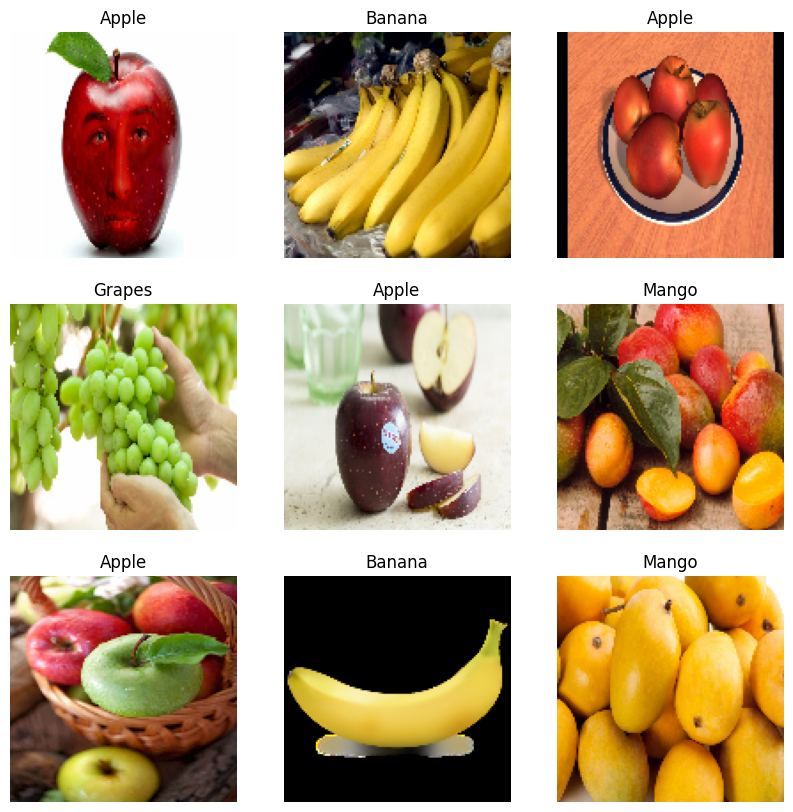

In [5]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

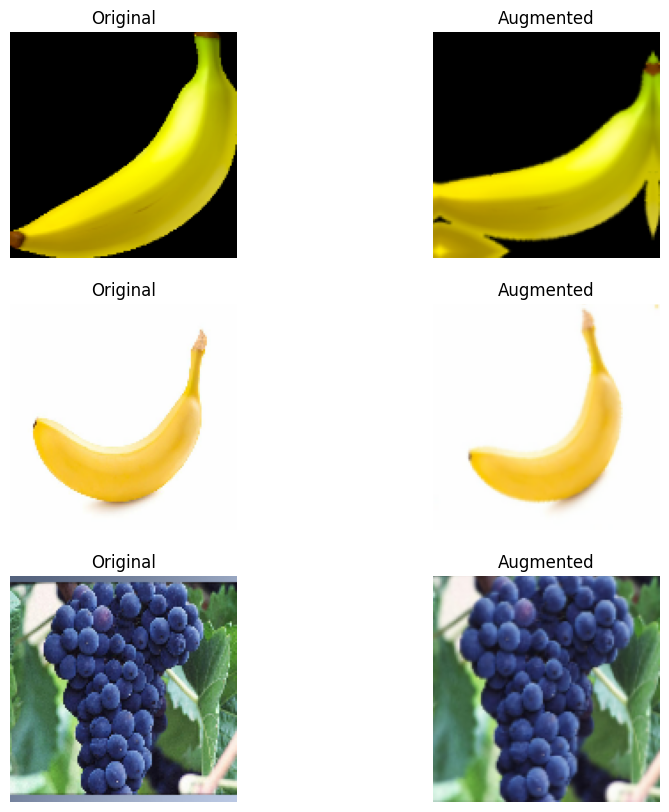

In [8]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(3):

        # ORIGINAL IMAGE
        ax = plt.subplot(3, 2, 2 * i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title("Original")
        plt.axis("off")

        # AUGMENTED IMAGE
        augmented_image = data_augmentation(
            tf.expand_dims(images[i], 0)
        )

        ax = plt.subplot(3, 2, 2 * i + 2)

        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.title("Augmented")
        plt.axis("off")

plt.show()

In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [10]:
normalized_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [11]:
for images, labels in normalized_dataset.take(1):

    first_image = images[0]

    print("Minimum pixel value:", np.min(first_image))
    print("Maximum pixel value:", np.max(first_image))

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [12]:
# CNN model for fruit classification

model = tf.keras.Sequential([

    # Data augmentation
    data_augmentation,

    # Normalize pixel values
    normalization_layer,

    # First convolution block
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # Second convolution block
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # Third convolution block
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # Convert feature maps into single vector
    tf.keras.layers.Flatten(),

    # Dense neural network layer
    tf.keras.layers.Dense(128, activation='relu'),

    # Output layer (4 fruit classes)
    tf.keras.layers.Dense(4, activation='softmax')
])

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 128, 128, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (32, 128, 128, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 126, 126, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 63, 63, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 61, 61, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 28, 28, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 14, 14, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 25088)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 128)              │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 4)                │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Configure model training

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    "../dataset/validation",
    image_size=(128, 128),
    batch_size=32
)

Found 38 files belonging to 4 classes.


In [16]:
# Train the CNN model

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 24s 555ms/step - accuracy: 0.3556 - loss: 1.3555 - val_accuracy: 0.6316 - val_loss: 1.0181
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 702ms/step - accuracy: 0.6049 - loss: 0.9009 - val_accuracy: 0.7105 - val_loss: 0.9893
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 540ms/step - accuracy: 0.6960 - loss: 0.7400 - val_accuracy: 0.8158 - val_loss: 0.8918
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 603ms/step - accuracy: 0.7295 - loss: 0.6094 - val_accuracy: 0.8158 - val_loss: 1.0347
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 620ms/step - accuracy: 0.7295 - loss: 0.6694 - val_accuracy: 0.8158 - val_loss: 0.6496
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 538ms/step - accuracy: 0.7538 - loss: 0.5840 - val_accuracy: 0.8158 - val_loss: 0.4776
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 625ms/step - accuracy: 0.7812 - loss: 0.5799 - val_accuracy: 0.8158 - val_loss: 0.7350
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 593ms/step - accuracy: 0.7964 - loss: 0.5038 - val_accuracy: 0

In [17]:
# Save trained model

model.save("../model/fruit_model.h5")

In [18]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "../dataset/test",
    image_size=(128, 128),
    batch_size=32
)

Found 39 files belonging to 4 classes.


In [19]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.8718 - loss: 0.4765
Test Accuracy: 87.18%
